In [ ]:
import os
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

from src._config import DEFAULT_CLUSTERING_DIR, DEFAULT_DATASET_DIR, DEFAULT_N_JOBS

for _var in (
    "OMP_NUM_THREADS",
    "MKL_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
):
    os.environ[_var] = str(DEFAULT_N_JOBS)

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

from src.clustering import fit_predict

DEFAULT_STYLE = ".matplotlib/paper.mplstyle"
plt.style.use(DEFAULT_STYLE)

# Toggle to `True` to save outputs
save_output = False

In [ ]:
KEY = ["video_id", "bird_id", "window"]
RANDOM_SEED = 42

ROOT = Path.cwd().parent
DS = ROOT / DEFAULT_DATASET_DIR
OUT = ROOT / DEFAULT_CLUSTERING_DIR
OUT_IMG = ROOT / "img/"
OUT_IMG.mkdir(parents=True, exist_ok=True)

lab = pd.read_parquet(DS / "labels.parquet", columns=KEY + ["behav_label"])
lab = lab[lab.behav_label != "social"].reset_index(drop=True)

fw = lab.merge(pd.read_parquet(DS / "features_windowed.parquet"), on=KEY, how="left")
feat_cols = [c for c in fw.columns if c not in {*KEY, "behav_label", "n_frames"}]

X = fw[feat_cols].astype(float)
y = lab.behav_label.to_numpy()

X.shape, y.shape

((14515, 171), (14515,))

In [3]:
X_dropna = X.dropna()

Z_dropna_path = Path(f"{OUT}/Z_dropna.npy")
if Z_dropna_path.exists():
    Z_dropna = np.load(Z_dropna_path)
else:
    Z_dropna = StandardScaler().fit_transform(X_dropna)

print(f"dropna: {X_dropna.shape[0]} rows, Z_dropna {Z_dropna.shape}")

dropna: 12989 rows, Z_dropna (12989, 171)


In [4]:
from sklearn.metrics import adjusted_rand_score

# HAC k=2 on dropna
res = fit_predict(Z_dropna, solver="hac", k=2, random_state=RANDOM_SEED)
cluster_labels = res.labels

# true labels (aligned with dropna rows)
y_dropna = y[X_dropna.index]

# ARI
ari = adjusted_rand_score(y_dropna, cluster_labels)
print(f"HAC k=2, dropna: ARI = {ari:.3f}")
print(f"Cluster sizes: {res.sizes}")
print(f"Label distribution: {pd.Series(y_dropna).value_counts().to_dict()}")

# t-SNE
tsne = TSNE(n_components=2, random_state=RANDOM_SEED)
Z_tsne = tsne.fit_transform(Z_dropna)
print(f"t-SNE: {Z_tsne.shape}")

HAC k=2, dropna: ARI = 0.426
Cluster sizes: [11071, 1918]
Label distribution: {'none': 11083, 'worm': 1329, 'locomotor': 577}
t-SNE: (12989, 2)


In [5]:
cluster_ethogram = pd.crosstab(
    y_dropna, cluster_labels, rownames=["ethogram"], colnames=["cluster"], normalize=0
)
cluster_ethogram

cluster,0,1
ethogram,,
locomotor,0.131716,0.868284
none,0.926103,0.073897
worm,0.550038,0.449962


In [ ]:
if save_output:
    cluster_ethogram.to_csv(f"{OUT}/cluster_assignments.csv")

In [ ]:
with plt.style.context(DEFAULT_STYLE):
    sns.heatmap(
        pd.crosstab(
            y_dropna,
            cluster_labels,
            rownames=["ethogram"],
            colnames=["cluster"],
            normalize=0,
        ),
        annot=True,
        square=True,
        cmap="RdBu",
        fmt=".2f",
        cbar_kws={"shrink": 0.75, "label": "Proportion of ethogram category"},
        annot_kws={"fontsize": 10},
    )
    plt.xlabel("Morphokinematic cluster", fontweight="bold")
    plt.ylabel("Ethogram category", fontweight="bold")
    plt.title(f"Adjusted Rand Index: {ari:.3f}", fontweight="bold")
    if save_output:
        plt.savefig(OUT_IMG / "fig2_cluster_heatmap.pdf", bbox_inches="tight", dpi=300)
        plt.savefig(OUT_IMG / "fig2_cluster_heatmap.png", bbox_inches="tight", dpi=300)

In [7]:
lab_fine = pd.read_parquet(
    DS / "labels.parquet", columns=KEY + ["behav_label", "behav"]
)
lab_fine = lab_fine[lab_fine.behav_label != "social"].reset_index(drop=True)
behav_fine = lab_fine.loc[X_dropna.index, "behav"].values

ari_fine = adjusted_rand_score(behav_fine, cluster_labels)
print(f"ARI (coarse):       {ari:.3f}")
print(f"ARI (fine-grained): {ari_fine:.3f}")

pd.crosstab(
    behav_fine,
    cluster_labels,
    rownames=["sub-behaviour"],
    colnames=["cluster"],
    normalize=0,
)

ARI (coarse):       0.426
ARI (fine-grained): 0.433


cluster,0,1
sub-behaviour,,
Frolicking,0.125773,0.874227
"Frolicking, Spinning while wing flapping",1.000000,0.000000
"Frolicking, Wing flapping",0.000000,1.000000
"Frolicking, Worm chasing",0.000000,1.000000
"Frolicking, Worm pecking",0.111111,0.888889
"Frolicking, Worm running",0.333333,0.666667
"Frolicking, Worm running mealworm",0.000000,1.000000
Running,0.357143,0.642857
"Running, Frolicking, Worm pecking",0.000000,1.000000


In [ ]:
LABEL_COL = {"none": "#999999", "worm": "#E69F00", "locomotor": "#0072B2"}
CLUSTER_COL = {0: "#debb9b", 1: "#2ca02c"}
WORM_ACTIVE_COL = "#7614D0"  # purple for running/chasing worm behaviours
DEFAULT_STYLE = ".matplotlib/paper.mplstyle"


def shade_ramp(hex_colour, n):
    """n shades from light to dark within one hue."""
    base = np.array(mcolors.to_rgb(hex_colour))
    if n == 1:
        return [hex_colour]
    shades = []
    for t in np.linspace(0.3, 1.0, n):
        shades.append(mcolors.to_hex(base * t + (1 - t) * np.ones(3) * 0.85))
    return shades


def is_worm_active(label):
    """Worm behaviours involving running or chasing."""
    lower = label.lower()
    return "running" in lower or "chasing" in lower


# map each fine label to its coarse category
lab_fine_map = pd.read_parquet(
    "../data/dataset/labels.parquet", columns=KEY + ["behav_label", "behav"]
)
lab_fine_map = lab_fine_map[lab_fine_map.behav_label != "social"].reset_index(drop=True)
lab_fine_map.behav = lab_fine_map.behav.apply(lambda x: x.split(", ")[0])
behav_to_cat = dict(zip(lab_fine_map.behav, lab_fine_map.behav_label))

# split worm into active (running/chasing -> purple) and rest (-> orange)
worm_active = sorted([
    b for b, c in behav_to_cat.items() if c == "worm" and is_worm_active(b)
])
worm_other = sorted([
    b for b, c in behav_to_cat.items() if c == "worm" and not is_worm_active(b)
])

fine_col = {}
for label, colour in zip(
    sorted([b for b, c in behav_to_cat.items() if c == "none"]),
    shade_ramp(
        LABEL_COL["none"], len([b for b, c in behav_to_cat.items() if c == "none"])
    ),
):
    fine_col[label] = colour
for label, colour in zip(worm_active, shade_ramp(WORM_ACTIVE_COL, len(worm_active))):
    fine_col[label] = colour
for label, colour in zip(worm_other, shade_ramp(LABEL_COL["worm"], len(worm_other))):
    fine_col[label] = colour
loco_members = sorted([b for b, c in behav_to_cat.items() if c == "locomotor"])
for label, colour in zip(
    loco_members, shade_ramp(LABEL_COL["locomotor"], len(loco_members))
):
    fine_col[label] = colour

# --- Ethogram categories (coarse) ---
with plt.style.context(DEFAULT_STYLE):
    fig1, ax1 = plt.subplots(figsize=(6, 5))
    for label in ["none", "worm", "locomotor"]:
        mask = y_dropna == label
        ax1.scatter(
            Z_tsne[mask, 0],
            Z_tsne[mask, 1],
            s=12,
            alpha=0.8,
            c=LABEL_COL[label],
            label=label.title(),
            edgecolors="none",
            rasterized=True,
        )
    ax1.set_xlabel("t-SNE 1")
    ax1.set_ylabel("t-SNE 2")
    ax1.legend(markerscale=4, title="Ethogram category")
    sns.despine()
    plt.tight_layout()
    if save_output:
        plt.savefig(OUT_IMG / "fig2_tsne_ethogram.pdf", bbox_inches="tight", dpi=300)
        plt.savefig(OUT_IMG / "fig2_tsne_ethogram.png", bbox_inches="tight", dpi=300)
    plt.show()

# --- Ethogram sub-behaviours ---
with plt.style.context(DEFAULT_STYLE):
    fig2, ax2 = plt.subplots(figsize=(6, 5))
    present = set(behav_fine)

    # Draw scatter (same draw order as before)
    draw_order = [
        sorted([b for b in present if behav_to_cat.get(b) == "none"]),
        [b for b in worm_other if b in present],
        [b for b in worm_active if b in present],
        sorted([b for b in present if behav_to_cat.get(b) == "locomotor"]),
    ]
    for group in draw_order:
        for label in group:
            mask = behav_fine == label
            ax2.scatter(
                Z_tsne[mask, 0],
                Z_tsne[mask, 1],
                s=12,
                alpha=0.8,
                c=fine_col[label],
                label=label,
                edgecolors="none",
                rasterized=True,
            )
    ax2.set_xlabel("t-SNE 1")
    ax2.set_ylabel("t-SNE 2")
    sns.despine(ax=ax2)

    # Build grouped entries: (color, label) per group
    g_none = [
        (fine_col[b], b)
        for b in sorted(b for b in present if behav_to_cat.get(b) == "none")
    ]
    g_worm_other = [(fine_col[b], b) for b in worm_other if b in present]
    g_worm_active = [(fine_col[b], b) for b in worm_active if b in present]
    g_loco = [
        (fine_col[b], b)
        for b in sorted(b for b in present if behav_to_cat.get(b) == "locomotor")
    ]

    columns = [
        ("None", g_none),
        ("Worm (other)", g_worm_other),
        ("Worm (active)", g_worm_active),
        ("Locomotor", g_loco),
    ]

    # Legend below plot
    leg_ax = fig2.add_axes([0.05, 0.75, 0.8, 0.35])
    leg_ax.set_xlim(0, 1)
    leg_ax.set_ylim(0, 1)
    leg_ax.axis("off")

    n_cols = len(columns)
    col_x = [0.1, 0.2, 0.45, 0.8]
    row_height = 0.12

    for col_idx, (header, entries) in enumerate(columns):
        x = col_x[col_idx]
        y_start = 0.95
        if header:
            leg_ax.text(
                x,
                y_start,
                header,
                fontweight="bold",
                fontsize=8,
                va="center",
                transform=leg_ax.transAxes,
            )
        for row_idx, (color, label) in enumerate(entries):
            y = y_start - (row_idx + 1) * row_height
            leg_ax.scatter(
                x + 0.005,
                y,
                c=[color],
                s=18,
                transform=leg_ax.transAxes,
                clip_on=False,
            )
            leg_ax.text(
                x + 0.02,
                y,
                label,
                va="center",
                transform=leg_ax.transAxes,
            )

    if save_output:
        plt.savefig(
            OUT_IMG / "fig2_tsne_subbehaviours.pdf", bbox_inches="tight", dpi=300
        )
        plt.savefig(
            OUT_IMG / "fig2_tsne_subbehaviours.png", bbox_inches="tight", dpi=300
        )
    plt.show()

# --- Cluster labels ---
with plt.style.context(DEFAULT_STYLE):
    fig3, ax3 = plt.subplots(figsize=(6, 5))
    for cl in range(2):
        mask = cluster_labels == cl
        ax3.scatter(
            Z_tsne[mask, 0],
            Z_tsne[mask, 1],
            s=12,
            alpha=0.6,
            c=CLUSTER_COL[cl],
            label=f"Cluster {cl}",
            edgecolors="none",
            rasterized=True,
        )
    ax3.set_xlabel("t-SNE 1")
    ax3.set_ylabel("t-SNE 2")
    ax3.legend(markerscale=4)
    sns.despine()
    plt.tight_layout()

    if save_output:
        plt.savefig(OUT_IMG / "fig2_tsne_cluster.pdf", bbox_inches="tight", dpi=300)
        plt.savefig(OUT_IMG / "fig2_tsne_cluster.png", bbox_inches="tight", dpi=300)
    plt.show()

In [9]:
pca6 = PCA(n_components=6).fit(Z_dropna)

print(f"Explained variance: {pca6.explained_variance_ratio_.round(3)}")
print(f"Cumulative: {np.cumsum(pca6.explained_variance_ratio_).round(3)}")

Explained variance: [0.19  0.077 0.066 0.048 0.036 0.032]
Cumulative: [0.19  0.266 0.332 0.38  0.415 0.447]


RC1: velocity (mean)=+0.93, velocity (q90)=+0.89, acceleration (q10)=-0.87, velocity (mad)=+0.85
RC2: solidity (q10)=+0.91, solidity (mean)=+0.89, circularity (cv)=-0.88, circularity (q10)=+0.87
RC3: elongation (q10)=+0.91, eccentricity (q10)=+0.89, eccentricity (mean)=+0.88, elongation (mean)=+0.83
RC4: min_dist_to_other (mean)=-0.87, mean_dist_to_other (mean)=-0.86, mean_dist_to_other (median)=-0.85, min_dist_to_other (median)=-0.84
RC5: velocity (skew)=+0.82, velocity (cv)=+0.81, velocity_autocorr (cv)=+0.79, acceleration (kurt)=+0.78
RC6: turning_angle (mean)=+0.76, turning_angle (skew)=-0.75, turning_angle (median)=+0.70, turning_angle (q90)=+0.65


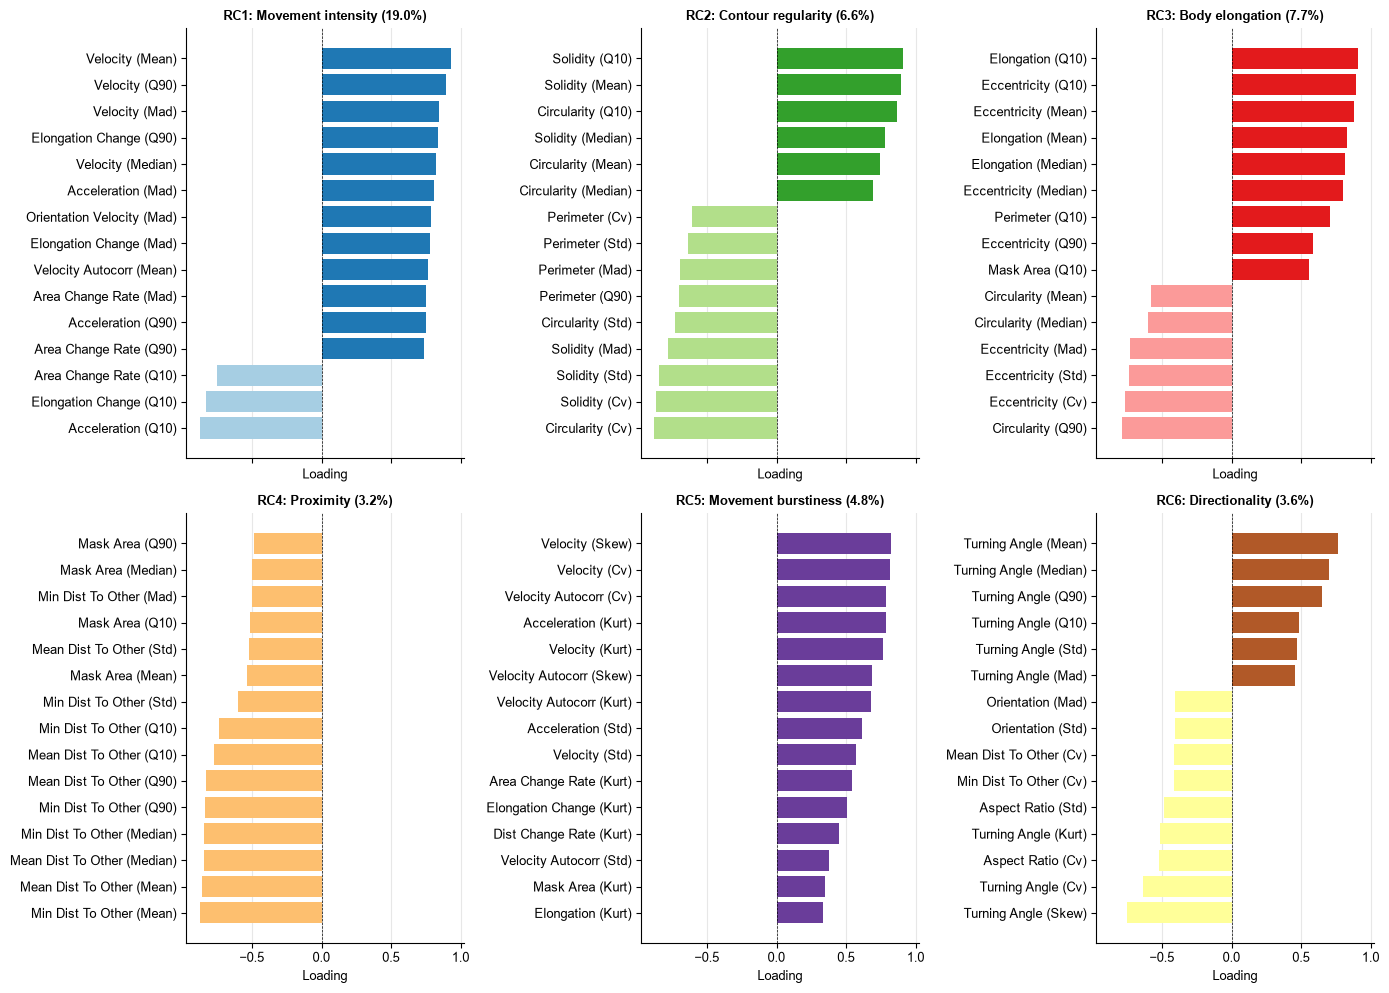

In [10]:
def varimax(Phi, max_iter=100, tol=1e-6):
    """Varimax rotation on a loadings matrix (n_features x n_components)."""
    p, k = Phi.shape
    R = np.eye(k)
    d = 0
    for _ in range(max_iter):
        d_old = d
        Lambda = Phi @ R
        u, s, vt = np.linalg.svd(
            Phi.T
            @ (Lambda**3 - (Lambda * np.sum(Lambda**2, axis=0, keepdims=True)) / p)
        )
        R = u @ vt
        d = np.sum(s)
        if d - d_old < tol:
            break
    return Phi @ R


# Varimax-rotated loadings
raw_loadings = pca6.components_.T * np.sqrt(pca6.explained_variance_)
rotated_loadings = varimax(raw_loadings)

# Reorder components by explained rotated variance (descending)
rot_var = (rotated_loadings**2).sum(axis=0)
order = np.argsort(rot_var)[::-1]
rotated_loadings = rotated_loadings[:, order]

# Signal names from feature columns
feat_cols = [c for c in fw.columns if c not in {*KEY, "behav_label", "n_frames"}]
signal_names = ["_".join(c.split("_")[:-1]) for c in feat_cols]
stat_names = [c.split("_")[-1] for c in feat_cols]

df_loadings = pd.DataFrame(
    rotated_loadings,
    index=[f"{s} ({st})" for s, st in zip(signal_names, stat_names)],
    columns=[f"RC{i + 1}" for i in range(6)],
)

# Print: top-4 per component
for rc in df_loadings.columns:
    top_idx = df_loadings[rc].abs().nlargest(4).index
    top = ", ".join(f"{feat}={df_loadings.loc[feat, rc]:+.2f}" for feat in top_idx)
    print(f"{rc}: {top}")

RC_NAMES = [
    "Movement intensity",
    "Contour regularity",
    "Body elongation",
    "Proximity",
    "Movement burstiness",
    "Directionality",
]

# Plot: horizontal bar chart per RC, showing top 15 features by |loading|
fig, axes = plt.subplots(2, 3, figsize=(14, 10), sharex=True)
paired = plt.cm.Paired.colors

with plt.style.context(".matplotlib/paper.mplstyle"):
    for i, (rc, ax) in enumerate(zip(df_loadings.columns, axes.ravel())):
        top15 = df_loadings[rc].abs().nlargest(15).index
        sorted_vals = df_loadings.loc[top15, rc].sort_values()
        col_neg, col_pos = paired[2 * i], paired[2 * i + 1]
        colors = [col_neg if v < 0 else col_pos for v in sorted_vals]

        y = np.arange(len(sorted_vals))
        ax.barh(y, sorted_vals.values, color=colors)
        ax.set_yticks(y)
        ax.set_yticklabels([idx.replace("_", " ").title() for idx in sorted_vals.index])
        ax.set_xlabel("Loading")
        ax.set_title(
            f"{rc}: {RC_NAMES[i]} ({pca6.explained_variance_ratio_[order[i]]:.1%})",
            fontweight="bold",
        )
        ax.axvline(0, color="k", linewidth=0.5, linestyle="--")
        ax.set_axisbelow(True)
        ax.grid(alpha=0.3, axis="x")

    plt.tight_layout()
    sns.despine()
    if save_output:
        plt.savefig(OUT_IMG / "figS_loadings.pdf", dpi=300)
        plt.savefig(OUT_IMG / "figS_loadings.png", dpi=300)
    plt.show()

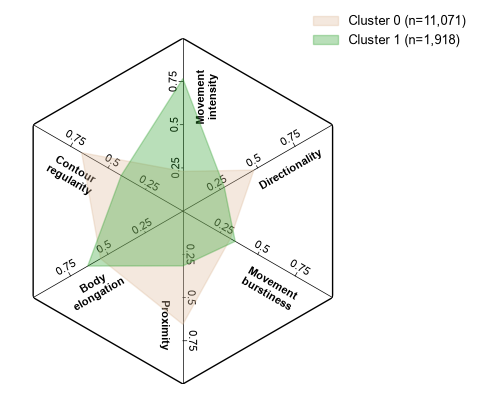

In [11]:
def plot_radar(
    cluster_means,
    labels,
    colors,
    spoke_labels,
    sds=None,
    grid_rings=None,
    outer_color="#E6BD77",
):
    """Radar chart with one polygon per cluster, overlaid on a single polar plot.

    If `sds` is provided (same shape as cluster_means), dashed lines show mean +/- SD.
    """
    if grid_rings is None:
        grid_rings = [0.25, 0.5, 0.75, 1.0]

    n_spokes = len(spoke_labels)
    angles = np.linspace(0, 2 * np.pi, n_spokes, endpoint=False).tolist()
    angles += angles[:1]

    with plt.style.context(".matplotlib/paper.mplstyle"):
        fig, ax = plt.subplots(figsize=(5, 5), subplot_kw=dict(polar=True))

        for i, (values, label, color) in enumerate(zip(cluster_means, labels, colors)):
            closed = values.tolist() + [values[0]]
            ax.fill(angles, closed, alpha=0.33, color=color, zorder=10, label=label)
            # ax.plot(angles, closed, color=color, linewidth=1.5, label=label)

            if sds is not None:
                lo = np.clip(values - sds[i], 0, None).tolist()
                hi = (values + sds[i]).tolist()
                lo += lo[:1]
                hi += hi[:1]
                ax.plot(
                    angles, lo, color=color, linewidth=0.8, linestyle="--", alpha=0.6
                )
                ax.plot(
                    angles, hi, color=color, linewidth=0.8, linestyle="--", alpha=0.6
                )

        rmax = max(grid_rings)
        if sds is not None:
            rmax = max(rmax, (cluster_means + sds).max() * 1.05)
        ax.set_ylim(0, rmax)
        ax.set_xticks([])

        ax.yaxis.grid(False)
        ax.spines["polar"].set_visible(False)

        # Spoke lines (radial axes) from center to outer ring
        for angle in angles[:-1]:
            ax.plot([angle, angle], [0, rmax], color="black", linewidth=0.5)

        ax.set_theta_offset(np.pi / 2)

        # Standard matplotlib radial ticks
        ax.set_yticks([])
        # ax.set_yticklabels([f"{r}" for r in grid_rings[:-1]], fontsize=8)
        ax.set_rlabel_position(angles[0] * 180 / np.pi)
        ax.tick_params(axis="y", direction="inout", length=4, width=0.5)

        # Tick labels on every spoke, and dimension titles
        tick_len = 0.03
        for i, angle in enumerate(angles[:-1]):
            screen_deg = (np.degrees(angle) + 90) % 360
            if 90 < screen_deg < 270:
                rot = screen_deg - 180
                tick_dir = -tick_len
            else:
                rot = screen_deg
                tick_dir = tick_len

            # Tick labels on each grid ring (except outermost)
            for r in grid_rings[:-1]:
                ax.text(
                    angle + tick_dir,
                    r,
                    f"{r}",
                    ha="center",
                    va="bottom",
                    fontsize=8,
                    rotation=rot,
                    rotation_mode="anchor",
                )
                ax.plot([angle, angle + tick_dir], [r, r], color="black", linewidth=0.5)

            # Title under: centered along the spoke, inside the radar
            ax.text(
                angle,
                rmax * 0.66,
                "\n" + spoke_labels[i],
                ha="center",
                va="top",
                fontsize=8,
                rotation=rot,
                rotation_mode="anchor",
                fontweight="bold",
            )

        ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1))

        # Outer boundary
        ax.plot(angles, [rmax] * len(angles), color="k", linewidth=1)

        plt.tight_layout()
    return fig, ax


def bootstrap_ci(x, n_bootstrap=1000, ci=95):
    """Bootstrap confidence interval for a 1D array."""
    bootstraps = np.random.choice(x, size=(n_bootstrap, len(x)), replace=True)
    means = bootstraps.mean(axis=1)
    lower = np.percentile(means, (100 - ci) / 2)
    upper = np.percentile(means, 100 - (100 - ci) / 2)
    return lower, upper


RC_LABELS = [
    "Movement\nintensity",
    "Contour\nregularity",
    "Body\nelongation",
    "Proximity",
    "Movement\nburstiness",
    "Directionality",
]

R_varimax = np.linalg.lstsq(raw_loadings, rotated_loadings, rcond=None)[0]
Z_rotated = Z_dropna @ pca6.components_.T @ R_varimax
q05 = np.percentile(Z_rotated, 5, axis=0)
q95 = np.percentile(Z_rotated, 95, axis=0)
Z_rotated_scaled = np.clip((Z_rotated - q05) / (q95 - q05), 0, 1)

cluster_means = np.array([
    Z_rotated_scaled[cluster_labels == cl].mean(axis=0) for cl in range(2)
])
cluster_sds = np.array([
    Z_rotated_scaled[cluster_labels == cl].std(axis=0) for cl in range(2)
])
# cluster_boot90 = np.array([
#     [
#         bootstrap_ci(Z_rotated_scaled[cluster_labels == cl, i], n_bootstrap=1000, ci=90)
#         for i in range(Z_rotated_scaled.shape[1])
#     ]
#     for cl in range(2)
# ])

plot_radar(
    cluster_means,
    labels=[
        f"Cluster {cl} (n={int((cluster_labels == cl).sum()):,})" for cl in range(2)
    ],
    colors=[CLUSTER_COL[0], CLUSTER_COL[1]],
    spoke_labels=RC_LABELS,
    # sds=cluster_sds,
)
if save_output:
    plt.savefig(OUT_IMG / "fig2_radar.pdf", bbox_inches="tight", dpi=300)
    plt.savefig(OUT_IMG / "fig2_radar.png", bbox_inches="tight", dpi=300)
plt.show()

In [12]:
# Supp: cluster vs. k for dropna

In [ ]:
grid_dropna = pd.read_csv(f"{OUT}/grid_dropna.csv")

with plt.style.context(DEFAULT_STYLE):
    sns.lineplot(
        data=grid_dropna,
        x="k",
        y="silhouette",
        hue="solver",
        marker="o",
        markersize=5,
        linewidth=1.5,
    )
    plt.xlabel("Number of clusters (k)")
    plt.ylabel("Silhouette score")
    plt.legend(title="Clustering method")
    if save_output:
        plt.savefig(OUT_IMG / "figS_cluster_vs_k.pdf", bbox_inches="tight", dpi=300)
        plt.savefig(OUT_IMG / "figS_cluster_vs_k.png", bbox_inches="tight", dpi=300)
    plt.show()